<a href="https://colab.research.google.com/github/sa8692/Examining-the-Flight-to-Safety-Mechanism-and-Covered-Interest-Parity-Deviations/blob/main/CIP_Deviations_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
#Merging all OECD dfs could be cooked
#Maybe remove high interest currencies?

In [ ]:
from google.colab import files

uploaded = files.upload()   # Choose the file

CIP_df = pd.read_csv(next(iter(uploaded)))  # Read the uploaded file
CIP_df.head()

Saving cip_dataset_v4 (1).csv to cip_dataset_v4 (1).csv


,group,currency,tenor,date,diff_y,rho,cip_govt,cip_govt_break_date,rho_ibor,rho_sofr,cip_govt_ibor,cip_govt_sofr
0,eme,BRL,10y,08feb2007,NaN,5.963500,NaN,26dec2023,5.963500,NaN,NaN,NaN
1,eme,BRL,10y,09feb2007,NaN,5.819000,NaN,26dec2023,5.819000,NaN,NaN,NaN
2,eme,BRL,10y,16feb2007,NaN,5.647000,NaN,26dec2023,5.647000,NaN,NaN,NaN
3,eme,BRL,10y,20feb2007,NaN,5.654399,NaN,26dec2023,5.654399,NaN,NaN,NaN
4,eme,BRL,10y,21feb2007,NaN,5.597750,NaN,26dec2023,5.597750,NaN,NaN,NaN


In [ ]:
CIP_df['tenor'].unique()

array(['10y', '1y', '20y', '2y', '30y', '3m', '3y', '5y', '7y'],
      dtype=object)

In [ ]:
g_10_currencies = ['USD', 'EUR', 'JPY', 'GBP', 'AUD', 'CAD', 'CHF', 'SEK', 'NZD', 'NOK']

In [ ]:
CIP_df = CIP_df[CIP_df['currency'].isin(g_10_currencies)]
CIP_df.index = pd.to_datetime(CIP_df['date'])

/tmp/ipython-input-1893421069.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  CIP_df.index = pd.to_datetime(CIP_df['date'])


In [ ]:
CIP_5y = CIP_df[CIP_df['tenor'] == '5y']

In [ ]:
CIP_10y = CIP_df[CIP_df['tenor'] == '10y']

In [ ]:
CIP_3M_df = CIP_df[CIP_df['tenor'] == '3m']

In [ ]:
def curr_df(currency_name, my_df):
  df_curr = my_df[my_df['currency'] == currency_name]
  curr_quarterly_dates = []
  i = df_curr.index[0]
  date_curr = df_curr.index[len(df_curr)-1]

  while pd.to_datetime(i) <= pd.to_datetime(date_curr):
    curr_quarterly_dates += [i]
    i = i + pd.DateOffset(days=1)

  df_curr = df_curr[df_curr.index.isin(curr_quarterly_dates)]
  #df_curr.set_index('date', inplace=True)

  return df_curr

In [ ]:
#5 Year Currency dfs
df_EUR = curr_df('EUR', CIP_5y)
df_JPY = curr_df('JPY', CIP_5y)
df_GBP = curr_df('GBP', CIP_5y)
df_AUD = curr_df('AUD', CIP_5y)
df_CAD = curr_df('CAD', CIP_5y)
df_CHF = curr_df('CHF', CIP_5y)
df_SEK = curr_df('SEK', CIP_5y)
df_NZD = curr_df('NZD', CIP_5y)
df_NOK = curr_df('NOK', CIP_5y)

#10 Year dfs

df_EUR_10 = curr_df('EUR', CIP_10y)
df_JPY_10 = curr_df('JPY', CIP_10y)
df_GBP_10 = curr_df('GBP', CIP_10y)
df_AUD_10 = curr_df('AUD', CIP_10y)
df_CAD_10 = curr_df('CAD', CIP_10y)
df_CHF_10 = curr_df('CHF', CIP_10y)
df_SEK_10 = curr_df('SEK', CIP_10y)
df_NZD_10 = curr_df('NZD', CIP_10y)
df_NOK_10 = curr_df('NOK', CIP_10y)

#3 Month dfs

df_EUR_3 = curr_df('EUR', CIP_3M_df)
df_JPY_3 = curr_df('JPY', CIP_3M_df)
df_GBP_3 = curr_df('GBP', CIP_3M_df)
df_AUD_3 = curr_df('AUD', CIP_3M_df)
df_CAD_3 = curr_df('CAD', CIP_3M_df)
df_CHF_3 = curr_df('CHF', CIP_3M_df)
df_SEK_3 = curr_df('SEK', CIP_3M_df)
df_NZD_3 = curr_df('NZD', CIP_3M_df)
df_NOK_3 = curr_df('NOK', CIP_3M_df)


In [ ]:
def consensus_array(df_arrays):
  i = 2
  consensus_df = pd.DataFrame()
  merged_df = pd.merge(df_arrays[0], df_arrays[1], left_index=True, right_index=True, how='left')
  consensus_df = np.array(merged_df['cip_govt_x'] + merged_df['cip_govt_y'])
  list_dates = np.array(df_arrays[0].index)

  while i < len(df_arrays):
    merged_df = pd.merge(df_arrays[0], df_arrays[i], left_index=True, right_index=True, how='left')
    consensus_df =  np.array(consensus_df) + np.array(merged_df['cip_govt_y'])
    i += 1
  consensus_df = consensus_df / 9
  output_df = pd.DataFrame(consensus_df, index=list_dates, columns=['Average CIP Deviations Across G10'])
  return output_df

In [ ]:
df_JPY_3

,group,currency,tenor,date,diff_y,rho,cip_govt,cip_govt_break_date,rho_ibor,rho_sofr,cip_govt_ibor,cip_govt_sofr
date,,,,,,,,,,,,
2000-01-03,g10,JPY,3m,03jan2000,-5.6400,-5.751770,11.176992,01jan2022,-5.751770,-5.751770,11.176992,NaN
2000-01-04,g10,JPY,3m,04jan2000,-5.6300,-5.729793,9.979250,01jan2022,-5.729793,-5.729793,9.979250,NaN
2000-01-05,g10,JPY,3m,05jan2000,-5.6200,-5.793139,17.313959,01jan2022,-5.793139,-5.793139,17.313959,NaN
2000-01-06,g10,JPY,3m,06jan2000,-5.5800,-5.770720,19.072010,01jan2022,-5.770720,-5.770720,19.072010,NaN
2000-01-07,g10,JPY,3m,07jan2000,-5.5700,-5.774090,20.408966,01jan2022,-5.774090,-5.774090,20.408966,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-24,g10,JPY,3m,24jun2025,-3.8824,-4.001323,11.892333,01jan2022,-4.001323,-4.001323,11.892333,11.892333
2025-06-25,g10,JPY,3m,25jun2025,-3.8824,-4.070912,18.851233,01jan2022,-4.070912,-4.070912,18.851233,18.851233
2025-06-26,g10,JPY,3m,26jun2025,-3.8797,-3.975887,9.618658,01jan2022,-3.975887,-3.975887,9.618658,9.618658


In [ ]:
final_avg_OECD_df = consensus_array([df_EUR, df_JPY, df_SEK, df_AUD, df_CAD, df_GBP, df_NOK, df_NZD, df_CHF])
final_avg_OECD_df = final_avg_OECD_df[final_avg_OECD_df.index >= '2004-01-01']
final_avg_OECD_df_2007 = final_avg_OECD_df[final_avg_OECD_df.index >= '2007-10-01']
final_avg_OECD_df_post_2020 = final_avg_OECD_df[final_avg_OECD_df.index >= '2020-01-01']
final_avg_OECD_df_post_2024 = final_avg_OECD_df[final_avg_OECD_df.index >= '2023-01-01']
final_avg_OECD_df_2025 = final_avg_OECD_df[final_avg_OECD_df.index >= '2025-01-01']

In [ ]:
avg_OECD_df_10y = consensus_array([df_EUR_10, df_JPY_10, df_SEK_10, df_AUD_10, df_CAD_10, df_GBP_10, df_NOK_10, df_NZD_10, df_CHF_10])
avg_OECD_df_10y = avg_OECD_df_10y[avg_OECD_df_10y.index >= '2004-01-01']

avg_OECD_df_3m = consensus_array([df_EUR_3, df_JPY_3, df_SEK_3, df_AUD_3, df_CAD_3, df_GBP_3, df_NOK_3, df_NZD_3, df_CHF_3])
avg_OECD_df_3m = avg_OECD_df_3m[avg_OECD_df_3m.index >= '2004-01-01']

In [ ]:
avg_OECD_df_10y[avg_OECD_df_10y.index >= '2016-01-01']

,Average CIP Deviations Across G10
2016-01-04,-19.728057
2016-01-05,-22.079065
2016-01-06,-20.448820
2016-01-07,-19.788876
2016-01-08,-21.688265
...,...
2025-06-24,-29.056102
2025-06-25,-29.029451
2025-06-26,-30.122989
2025-06-27,-29.498006


In [ ]:
avg_OECD_df_3m[avg_OECD_df_3m.index >= '2016-01-01']

,Average CIP Deviations Across G10
2016-01-01,NaN
2016-01-04,2.039225
2016-01-05,1.895950
2016-01-06,-1.160144
2016-01-07,1.205224
...,...
2025-06-24,0.951805
2025-06-25,3.479343
2025-06-26,0.331573
2025-06-27,2.257124


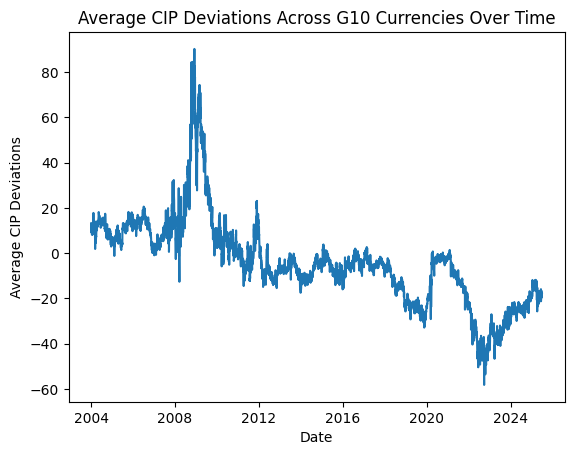

In [ ]:
plt.plot(final_avg_OECD_df.dropna())
plt.xlabel('Date')
plt.ylabel('Average CIP Deviations')
plt.title('Average CIP Deviations Across G10 Currencies Over Time')
plt.show()

Text(0.5, 1.0, 'Average CIP Deviations Across G10 Currencies Over Time (2020-)')

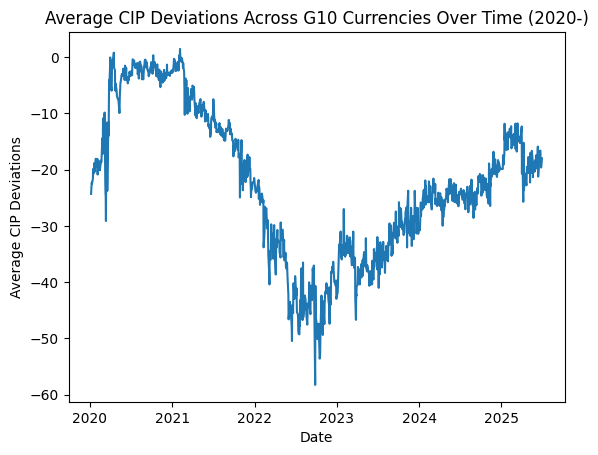

In [ ]:
plt.plot(final_avg_OECD_df_post_2020.dropna())
plt.xlabel('Date')
plt.ylabel('Average CIP Deviations')
plt.title('Average CIP Deviations Across G10 Currencies Over Time (2020-)')

Text(0.5, 1.0, 'Average CIP Deviations Across G10 Currencies in 2025')

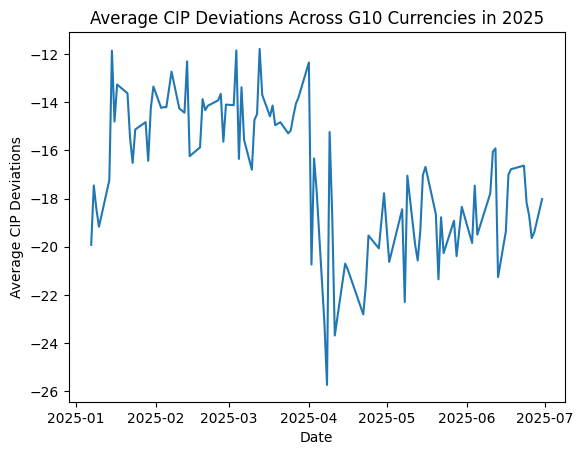

In [ ]:
plt.plot(final_avg_OECD_df_2025.dropna())
plt.xlabel('Date')
plt.ylabel('Average CIP Deviations')
plt.title('Average CIP Deviations Across G10 Currencies in 2025')
#.dropna

BBB Credit Spreads Analysis: https://fred.stlouisfed.org/series/BAMLC0A4CBBB

In [ ]:
#Access BBB Credit Spreads, will then correlate with avg CIP deviations
uploaded = files.upload()   # Choose the file

BBB_df = pd.read_csv(next(iter(uploaded)))  # Read the uploaded file
BBB_df.head()

Saving Credit_Spreads.csv to Credit_Spreads (6).csv


,observation_date,BAMLC0A4CBBB
0,1996-12-31,0.83
1,1997-01-01,NaN
2,1997-01-02,0.83
3,1997-01-03,0.83
4,1997-01-06,0.85


In [ ]:
BBB_df['observation_date'] = pd.to_datetime(BBB_df['observation_date'])
BBB_df.set_index('observation_date', inplace=True)

In [ ]:
BBB_CIP_OECD_df = pd.merge(final_avg_OECD_df, BBB_df, left_index=True, right_index=True, how='left')
BBB_CIP_OECD_df

,Average CIP Deviations Across G10,BAMLC0A4CBBB
2004-01-01,9.296674,NaN
2004-01-02,13.344462,1.29
2004-01-05,11.947803,1.27
2004-01-06,12.229996,1.27
2004-01-07,12.130227,1.27
...,...,...
2025-06-24,-18.168001,1.10
2025-06-25,-18.709781,1.11
2025-06-26,-19.642689,1.11
2025-06-27,-19.390908,1.10


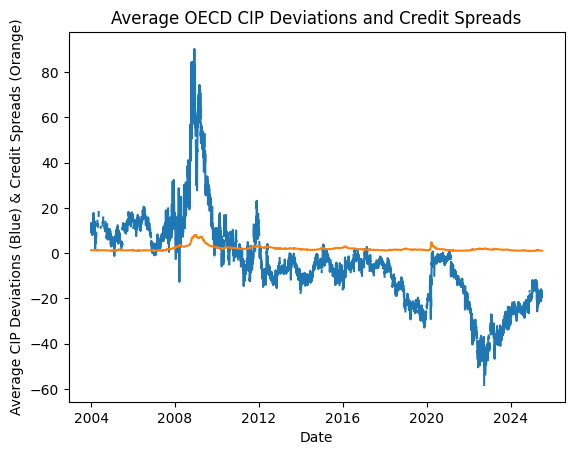

In [ ]:
plt.plot(BBB_CIP_OECD_df)
plt.xlabel('Date')
plt.ylabel('Average CIP Deviations (Blue) & Credit Spreads (Orange)')
plt.title('Average OECD CIP Deviations and Credit Spreads')
plt.show()

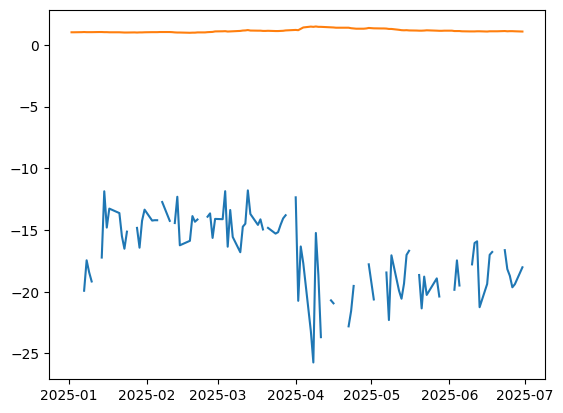

In [ ]:
import statsmodels.api as sm
BBB_CIP_OECD_df_2025 = BBB_CIP_OECD_df[BBB_CIP_OECD_df.index >= '2025-01-01']
plt.plot(BBB_CIP_OECD_df_2025)
#

In [ ]:
print('Investment Grade Spreads and Average CIP Deviations Across G10 are positively correlated at ' + str(BBB_CIP_OECD_df['Average CIP Deviations Across G10'].corr(BBB_CIP_OECD_df['BAMLC0A4CBBB'])))
print('Investment Grade Spreads and Average CIP Deviations Across G10 post 2025 are positively correlated at ' + str(BBB_CIP_OECD_df_2025['Average CIP Deviations Across G10'].corr(BBB_CIP_OECD_df_2025['BAMLC0A4CBBB'])))

Investment Grade Spreads and Average CIP Deviations Across G10 are positively correlated at 0.6442221707757307
Investment Grade Spreads and Average CIP Deviations Across G10 post 2025 are positively correlated at -0.5799038181487186


VIX Analysis: https://fred.stlouisfed.org/series/VIXCLS

In [ ]:
uploaded = files.upload()

VIX_df = pd.read_csv(next(iter(uploaded)))
VIX_df.head()

Saving VIX.csv to VIX (4).csv


,observation_date,VIXCLS
0,2000-01-03,24.21
1,2000-01-04,27.01
2,2000-01-05,26.41
3,2000-01-06,25.73
4,2000-01-07,21.72


In [ ]:
VIX_df['observation_date'] = pd.to_datetime(VIX_df['observation_date'])
VIX_df.set_index('observation_date', inplace=True)

In [ ]:
VIX_df_CIP = pd.merge(final_avg_OECD_df, VIX_df, left_index=True, right_index=True, how='left')
VIX_df_CIP_2025 = VIX_df_CIP[VIX_df_CIP.index >= '2025-01-01']

In [ ]:
print('Average CIP Deviations and VIX are positively correlated at ' + str(VIX_df_CIP['Average CIP Deviations Across G10'].corr(VIX_df_CIP['VIXCLS'])))
print('Average CIP Deviations and VIX post 2025 are positively correlated at ' + str(VIX_df_CIP_2025['Average CIP Deviations Across G10'].corr(VIX_df_CIP_2025['VIXCLS'])))

Average CIP Deviations and VIX are positively correlated at 0.4093821426298462
Average CIP Deviations and VIX post 2025 are positively correlated at -0.46181100078729026


USD Index: Bloomberg

In [ ]:
upload = files.upload()

USD_df = pd.read_csv(next(iter(upload)))
USD_df.head()

Saving Dollar_Index.csv to Dollar_Index (4).csv


,observation_date,DTWEXBGS
0,1/2/2006,101.4155
1,1/3/2006,100.7558
2,1/4/2006,100.2288
3,1/5/2006,100.2992
4,1/6/2006,100.0241


In [ ]:
USD_df['observation_date'] = pd.to_datetime(USD_df['observation_date'])
USD_df.set_index('observation_date', inplace=True)
USD_df_CIP = pd.merge(final_avg_OECD_df, USD_df, left_index=True, right_index=True, how='left')
USD_df_CIP_2025 = USD_df_CIP[USD_df_CIP.index >= '2025-01-01']

In [ ]:
print('Average CIP Deviations and USD Index are positively correlated at ' + str(USD_df_CIP['Average CIP Deviations Across G10'].corr(USD_df_CIP['DTWEXBGS'])))
print('Average CIP Deviations and USD Index post 2025 are positively correlated at ' + str(USD_df_CIP_2025['Average CIP Deviations Across G10'].corr(USD_df_CIP_2025['DTWEXBGS'])))

Average CIP Deviations and USD Index are positively correlated at -0.5746002087760546
Average CIP Deviations and USD Index post 2025 are positively correlated at 0.542898390552877


Correlation Matrix

In [ ]:
#Also put in MOVE, OFR FSI, GVZ

In [ ]:
merged_total_OECD_df = pd.merge(final_avg_OECD_df_2007, BBB_df[BBB_df.index >= '2007-10-01'], left_index=True, right_index=True, how='left')
merged_total_OECD_df = pd.merge(merged_total_OECD_df, VIX_df[VIX_df.index >= '2007-10-01'], left_index=True, right_index=True, how='left')
merged_total_OECD_df = pd.merge(merged_total_OECD_df, USD_df[USD_df.index >= '2007-10-01'], left_index=True, right_index=True, how='left')

merged_total_OECD_df.rename(columns={'Average CIP Deviations Across G10': 'G10 CIP Devs', 'BAMLC0A4CBBB': 'Credit Spreads', 'VIXCLS': 'VIX', 'DTWEXBGS': 'USD Index'}, inplace=True)

merged_total_2025_OECD_df = pd.merge(final_avg_OECD_df_2025, BBB_df[BBB_df.index >= '2025-01-01'], left_index = True, right_index = True, how = 'left')
merged_total_2025_OECD_df = pd.merge(merged_total_2025_OECD_df, VIX_df[VIX_df.index >= '2025-01-01'], left_index=True, right_index=True, how='left')
merged_total_2025_OECD_df = pd.merge(merged_total_2025_OECD_df, USD_df[USD_df.index >= '2025-01-01'], left_index=True, right_index=True, how='left')

merged_total_2025_OECD_df.rename(columns={'Average CIP Deviations Across G10': 'G10 CIP Devs', 'BAMLC0A4CBBB': 'Credit Spreads', 'VIXCLS': 'VIX Index', 'DTWEXBGS': 'USD Index'}, inplace=True)

Text(0.5, 1.0, 'Correlation Matrix of OECD Currencies Restricted to 2025')

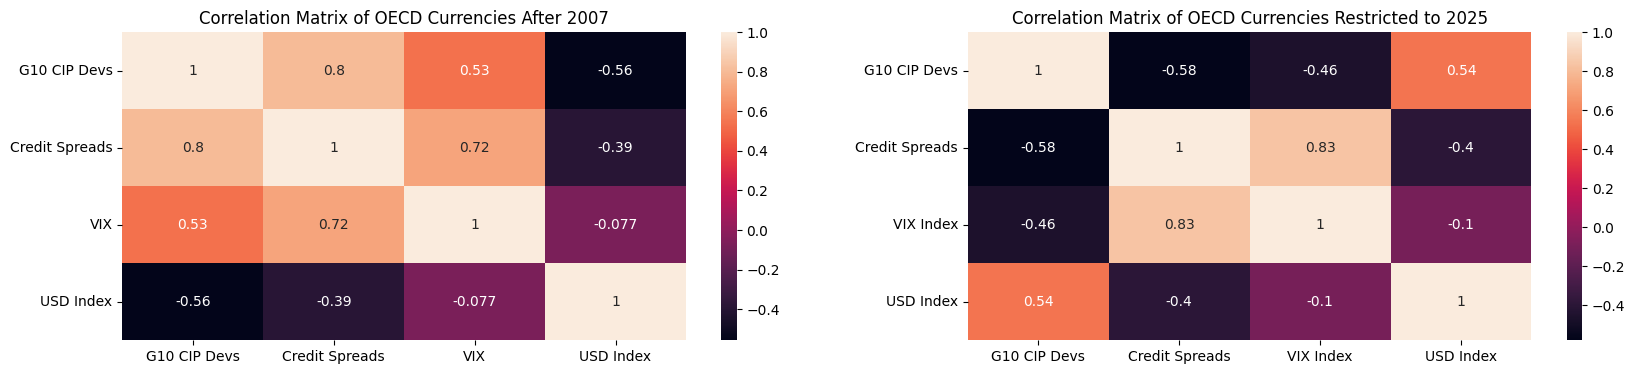

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

ax_1 = sns.heatmap(merged_total_OECD_df.corr(), annot=True, ax = axes[0])
ax_1.set_title('Correlation Matrix of OECD Currencies After 2007')
ax_1.tick_params(axis='x', rotation=0)

ax_2 = sns.heatmap(merged_total_2025_OECD_df.corr(), annot=True, ax = axes[1])
ax_2.tick_params(axis='x', rotation=0)
ax_2.set_title('Correlation Matrix of OECD Currencies Restricted to 2025')

Treasury Tenors and USD

In [ ]:
upload = files.upload()

Y10_df = pd.read_csv(next(iter(upload)))

Saving 10Y_Market_Yield.csv to 10Y_Market_Yield (3).csv


In [ ]:
#Get this from Bloomberg
upload = files.upload()
Euro_Rates = pd.read_csv(next(iter(upload)))

Saving 10Y_Eurozone_Rates.csv to 10Y_Eurozone_Rates (4).csv


In [ ]:
Y10_df['observation_date'] = pd.to_datetime(Y10_df['observation_date'])
Euro_Rates['observation_date'] = pd.to_datetime(Euro_Rates['observation_date'])

Y10_df.set_index('observation_date', inplace=True)
Euro_Rates.set_index('observation_date', inplace=True)

In [ ]:
Spread_df = pd.merge(Y10_df, Euro_Rates, left_index=True, right_index=True, how='right')
Spread_df['Spread'] = Spread_df['DGS10'] - Euro_Rates['IRLTLT01EZM156N']
Spread_df = Spread_df.dropna()

In [ ]:
merged_USD_Treasury_df = pd.merge(USD_df, Spread_df, left_index=True, right_index=True, how='right')
merged_USD_Treasury_df = merged_USD_Treasury_df.dropna()
merged_USD_Treasury_df['DTWEXBGS'] = merged_USD_Treasury_df['DTWEXBGS']/100
merged_USD_Treasury_df['Spread'] = merged_USD_Treasury_df['Spread']/merged_USD_Treasury_df['DGS10'][0]

/tmp/ipython-input-1521249353.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  merged_USD_Treasury_df['Spread'] = merged_USD_Treasury_df['Spread']/merged_USD_Treasury_df['DGS10'][0]


In [ ]:
merged_USD_Treasury_df

,DTWEXBGS,DGS10,IRLTLT01EZM156N,Spread
observation_date,,,,
2006-02-01,0.996132,4.57,3.551004,0.222975
2006-03-01,0.998355,4.59,3.731182,0.187925
2006-05-01,0.979085,5.14,4.060295,0.236259
2006-06-01,0.977726,5.11,4.075089,0.226458
2006-08-01,0.981715,4.99,3.968183,0.223592
...,...,...,...,...
2025-04-01,1.266783,4.17,3.097221,0.234744
2025-05-01,1.234811,4.25,3.070995,0.257988
2025-07-01,1.197678,4.26,3.173563,0.237732


In [ ]:
merged_USD_Treasury_df_2025 = merged_USD_Treasury_df[merged_USD_Treasury_df.index >= '2025-01-01']

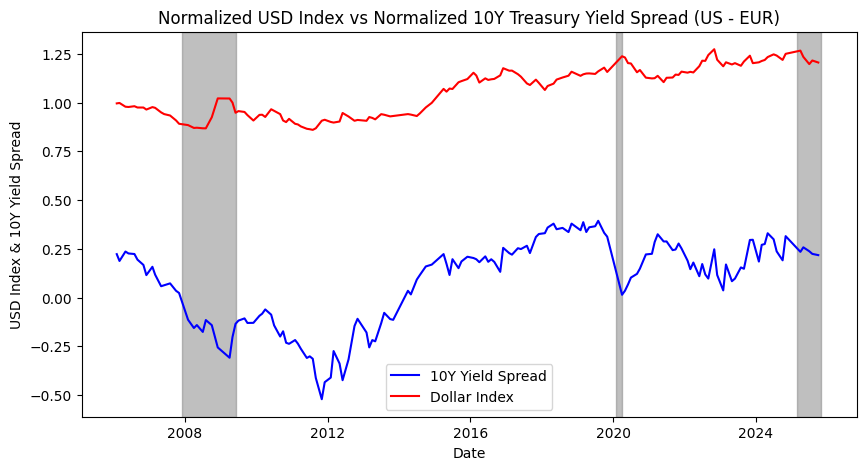

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.plot(merged_USD_Treasury_df['Spread'], label = '10Y Yield Spread', color = 'blue')
plt.plot(merged_USD_Treasury_df['DTWEXBGS'], label = 'Dollar Index', color = 'red')
plt.xlabel('Date')
plt.ylabel('USD Index & 10Y Yield Spread')
plt.title('Normalized USD Index vs Normalized 10Y Treasury Yield Spread (US - EUR)')

plt.axvspan('2007-12-01', '2009-06-01', color='grey', alpha=0.5)
plt.axvspan('2020-02-01', '2020-04-01', color='grey', alpha=0.5)
plt.axvspan('2025-03-01', '2025-11-01', color ='grey', alpha = 0.5)

plt.legend()
plt.show()

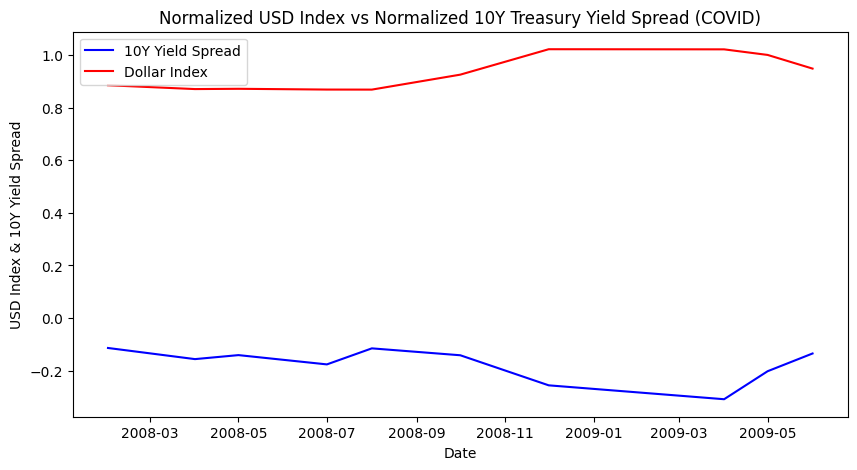

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.plot(merged_USD_Treasury_df.loc['2007-12-01':'2009-06-01']['Spread'], label = '10Y Yield Spread', color = 'blue')
plt.plot(merged_USD_Treasury_df.loc['2007-12-01':'2009-06-01']['DTWEXBGS'], label = 'Dollar Index', color = 'red')
plt.xlabel('Date')
plt.ylabel('USD Index & 10Y Yield Spread')
plt.title('Normalized USD Index vs Normalized 10Y Treasury Yield Spread (COVID)')

#plt.axvspan('2007-12-01', '2009-06-01', color='grey', alpha=0.5)
#plt.axvspan('2020-02-01', '2020-04-01', color='grey', alpha=0.5)
#plt.axvspan('2025-03-01', '2025-11-01', color ='grey', alpha = 0.5)

plt.legend()
plt.show()

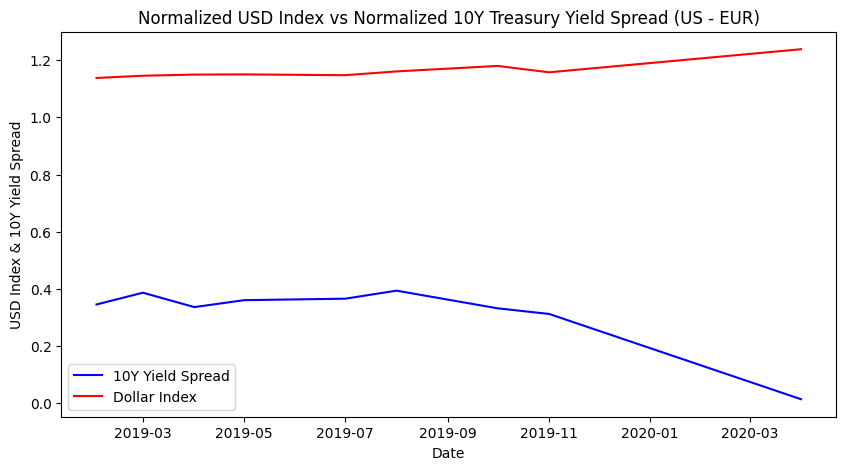

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.plot(merged_USD_Treasury_df.loc['2019-01-01':'2020-04-01']['Spread'], label = '10Y Yield Spread', color = 'blue')
plt.plot(merged_USD_Treasury_df.loc['2019-01-01':'2020-04-01']['DTWEXBGS'], label = 'Dollar Index', color = 'red')
plt.xlabel('Date')
plt.ylabel('USD Index & 10Y Yield Spread')
plt.title('Normalized USD Index vs Normalized 10Y Treasury Yield Spread (US - EUR)')

#plt.axvspan('2007-12-01', '2009-06-01', color='grey', alpha=0.5)
#plt.axvspan('2020-02-01', '2020-04-01', color='grey', alpha=0.5)
#plt.axvspan('2025-03-01', '2025-11-01', color ='grey', alpha = 0.5)

plt.legend()
plt.show()

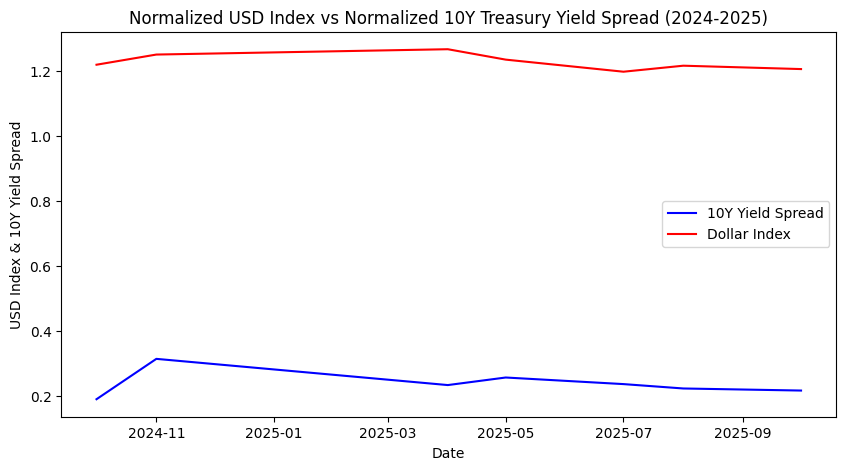

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plt.plot(merged_USD_Treasury_df.loc['2024-10-01':'2025-10-01']['Spread'], label = '10Y Yield Spread', color = 'blue')
plt.plot(merged_USD_Treasury_df.loc['2024-10-01':'2025-10-01']['DTWEXBGS'], label = 'Dollar Index', color = 'red')
plt.xlabel('Date')
plt.ylabel('USD Index & 10Y Yield Spread')
plt.title('Normalized USD Index vs Normalized 10Y Treasury Yield Spread (2024-2025)')

#plt.axvspan('2007-12-01', '2009-06-01', color='grey', alpha=0.5)
#plt.axvspan('2020-02-01', '2020-04-01', color='grey', alpha=0.5)
#plt.axvspan('2025-03-01', '2025-11-01', color ='grey', alpha = 0.5)

plt.legend()
plt.show()

In [ ]:
merged_USD_Treasury_df_Without_Recessions = pd.concat([merged_USD_Treasury_df[(merged_USD_Treasury_df.index < '2007-12-01')], merged_USD_Treasury_df[(merged_USD_Treasury_df.index > '2009-06-01')]])
merged_USD_Treasury_df_Without_Recessions = pd.concat([merged_USD_Treasury_df_Without_Recessions[merged_USD_Treasury_df_Without_Recessions.index < '2020-02-01'], merged_USD_Treasury_df_Without_Recessions[merged_USD_Treasury_df_Without_Recessions.index > '2020-04-01']])

In [ ]:
print('Average Yields and USD Index are positively correlated at ' + str(merged_USD_Treasury_df.loc['2009-06-01':'2019-01-01']['Spread'].corr(merged_USD_Treasury_df.loc['2009-06-01':'2019-01-01']['DTWEXBGS'])))

Average Yields and USD Index are positively correlated at 0.8867858795989361


In [ ]:
#Isolate Recessions/Flight-to-Safety Mechanisms
#You may find better results here

merged_USD_Treasury_df_Recessions = pd.concat([merged_USD_Treasury_df[(merged_USD_Treasury_df.index > '2008-12-01')], merged_USD_Treasury_df[(merged_USD_Treasury_df.index < '2009-06-01')]])
merged_USD_Treasury_df_Recessions = pd.concat([merged_USD_Treasury_df_Recessions[merged_USD_Treasury_df_Recessions.index > '2019-01-01'], merged_USD_Treasury_df_Recessions[merged_USD_Treasury_df_Recessions.index < '2020-04-01']])

merged_USD_Liberation_Day = merged_USD_Treasury_df[(merged_USD_Treasury_df.index >= '2025-01-01')]

In [ ]:
print('Correlation between 10Y and USD during recessions: ' + str(merged_USD_Treasury_df_Recessions['Spread'].corr(merged_USD_Treasury_df_Recessions['DTWEXBGS'])))

Correlation between 10Y and USD during recessions: 0.7536125628008699


In [ ]:
print('Correlation between 10Y and USD post Liberation Day: ' + str(merged_USD_Liberation_Day['Spread'].corr(merged_USD_Liberation_Day['DTWEXBGS'])))

Correlation between 10Y and USD post Liberation Day: 0.3323243575627388


In [ ]:
#Varying the timeframe for our 2025 dataframe leads to interesting result: First overwhelmingly positive correlation, then less positive post LD, then somewhat negative when restricted to data post May

Regression Using Credit Spreads, VIX, USD Index, and Dollar - Euro Rates as factors

In [ ]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [ ]:
merged_df_reg = merged_total_OECD_df[merged_total_OECD_df.index > '2007-12-01'].dropna()

In [ ]:
X = merged_df_reg[['Credit Spreads', 'VIX', 'USD Index']]
X_stats = X
X_stats = sm.add_constant(X_stats)
y = merged_df_reg['G10 CIP Devs']

In [ ]:
model = LinearRegression()
model.fit(X, y)
model_stats = sm.OLS(y, X_stats).fit()

In [ ]:
print(f"Model Intercept: {model.intercept_}")
print(f"Model Coefficients: {model.coef_}")

Model Intercept: 15.154661117870093
Model Coefficients: [ 1.20605324e+01 -3.29905349e-03 -4.43459948e-01]


In [ ]:
print(model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:           G10 CIP Devs   R-squared:                       0.722
Model:                            OLS   Adj. R-squared:                  0.722
Method:                 Least Squares   F-statistic:                     3347.
Date:                Fri, 12 Dec 2025   Prob (F-statistic):               0.00
Time:                        02:41:00   Log-Likelihood:                -14655.
No. Observations:                3874   AIC:                         2.932e+04
Df Residuals:                    3870   BIC:                         2.934e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             15.1547      1.783      8.

In [ ]:
merged_df_reg_Lib_Day = merged_total_OECD_df[merged_total_OECD_df.index > '2025-01-01'].dropna()

In [ ]:
X_Lib = merged_df_reg_Lib_Day[['Credit Spreads', 'VIX', 'USD Index']]
X_stats_Lib = X_Lib
X_stats_Lib = sm.add_constant(X_stats_Lib)
y_Lib = merged_df_reg_Lib_Day['G10 CIP Devs']

In [ ]:
model = LinearRegression()
model.fit(X_Lib, y_Lib)

model_stats = sm.OLS(y_Lib, X_stats_Lib).fit()

In [ ]:
print(f"Model Intercept: {model.intercept_}")
print(f"Model Coefficients: {model.coef_}")

Model Intercept: -68.04009432344682
Model Coefficients: [-4.12848257 -0.12210077  0.46635144]


In [ ]:
print(model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:           G10 CIP Devs   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     29.81
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           1.14e-13
Time:                        02:39:02   Log-Likelihood:                -215.49
No. Observations:                  99   AIC:                             439.0
Df Residuals:                      95   BIC:                             449.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -68.0401     13.234     -5.

CIP Deviations on 10Y Tenor

In [ ]:
#Correlation between 10Y CIP deviations with 10Y Treasuries
#Correlation between 3M devs and Libor-OIS or smth
avg_OECD_df_10y
avg_OECD_df_3m

,Average CIP Deviations Across G10
2004-01-01,10.270292
2004-01-02,13.379335
2004-01-05,11.610657
2004-01-06,10.271304
2004-01-07,6.841730
...,...
2025-06-24,0.951805
2025-06-25,3.479343
2025-06-26,0.331573
2025-06-27,2.257124


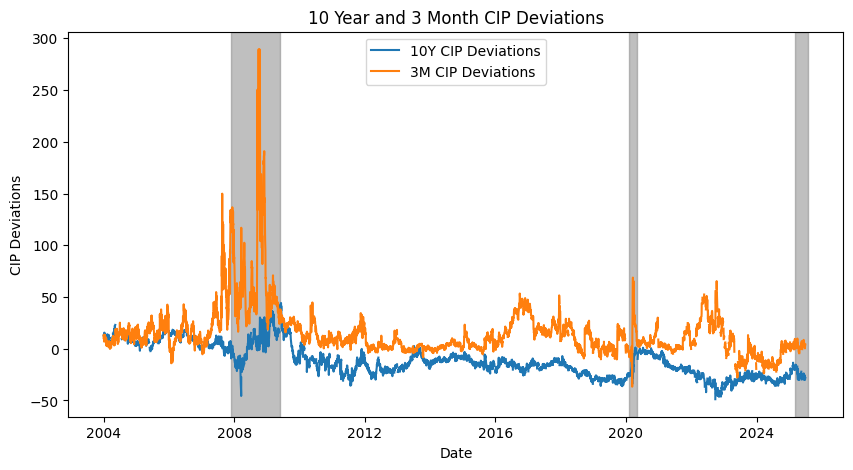

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(avg_OECD_df_10y, label = '10Y CIP Deviations')
plt.plot(avg_OECD_df_3m, label = '3M CIP Deviations')

plt.title('10 Year and 3 Month CIP Deviations')
plt.xlabel('Date')
plt.ylabel('CIP Deviations')

plt.axvspan('2007-12-01', '2009-06-01', color='grey', alpha=0.5)
plt.axvspan('2020-02-01', '2020-05-01', color='grey', alpha=0.5)
plt.axvspan('2025-03-01', '2025-08-01', color ='grey', alpha=0.5)

plt.legend()
plt.show()

In [ ]:
print('Volatility of 10Y CIP Devs in the GFC: ' + str(avg_OECD_df_10y.loc['2007-12-01':'2009-06-01']['Average CIP Deviations Across G10'].std()))
print('Volatility of 3M CIP Devs in the GFC: ' + str(avg_OECD_df_3m.loc['2007-12-01':'2009-06-01']['Average CIP Deviations Across G10'].std()))
#print('Variance of 3M CIP Devs in the GFC: '

Volatility of 10Y CIP Devs in the GFC: 15.532838205369197
Volatility of 3M CIP Devs in the GFC: 54.57933973410979


In [ ]:
print('Volatility of 10Y CIP Devs in the COVID Recession: ' + str(avg_OECD_df_10y.loc['2020-03-01':'2020-05-01']['Average CIP Deviations Across G10'].std()))
print('Volatility of 3M CIP Devs in the COVID Recession: ' + str(avg_OECD_df_3m.loc['2020-03-01':'2020-05-01']['Average CIP Deviations Across G10'].std()))

Volatility of 10Y CIP Devs in the COVID Recession: 8.988519758500825
Volatility of 3M CIP Devs in the COVID Recession: 24.64408131534231


In [ ]:
print('Volatility of 10Y CIP Devs During Liberation Day: ' + str(avg_OECD_df_10y.loc['2025-04-01':'2025-06-01']['Average CIP Deviations Across G10'].std()))
print('Volatility of 10Y CIP Devs During Liberation Day: ' + str(avg_OECD_df_3m.loc['2025-04-01':'2025-06-01']['Average CIP Deviations Across G10'].std()))

Volatility of 10Y CIP Devs During Liberation Day: 2.8985476523150955
Volatility of 10Y CIP Devs During Liberation Day: 2.8341478755824285


In [ ]:
avg_OECD_df_10y.loc['2007-12-01':'2009-06-01']['Average CIP Deviations Across G10'].corr(avg_OECD_df_3m.loc['2007-12-01':'2009-06-01']['Average CIP Deviations Across G10'])
#

np.float64(0.06571229133206481)

In [ ]:
avg_OECD_df_10y.loc['2020-03-01':'2020-05-01']['Average CIP Deviations Across G10'].corr(avg_OECD_df_3m.loc['2020-03-01':'2020-05-01']['Average CIP Deviations Across G10'])

np.float64(0.11830514727092159)

In [ ]:
avg_OECD_df_10y.loc['2025-04-01':'2025-06-01']['Average CIP Deviations Across G10'].corr(avg_OECD_df_3m.loc['2025-04-01':'2025-06-01']['Average CIP Deviations Across G10'])
#

np.float64(0.18378376687170087)

In [ ]:
avg_OECD_df_10y['Average CIP Deviations Across G10'].corr(avg_OECD_df_3m['Average CIP Deviations Across G10'])

np.float64(0.34931809973365086)

In [ ]:
#Interesting that the correlation broke down in 2025

10Y Yields and 10Y CIP Deviations

In [ ]:
#For these 2 sections, use a spread (10Y US Rates - Benchmark)

In [ ]:
avg_OECD_df_10y

,Average CIP Deviations Across G10
2004-01-01,12.951111
2004-01-02,12.210009
2004-01-05,12.398308
2004-01-06,11.992242
2004-01-07,14.144441
...,...
2025-06-24,-29.056102
2025-06-25,-29.029451
2025-06-26,-30.122989
2025-06-27,-29.498006


In [ ]:
merge_10Y_CIP = pd.merge(avg_OECD_df_10y, Y10_df, left_index=True, right_index=True, how='right')
merge_10Y_CIP = merge_10Y_CIP.dropna()
merge_10Y_CIP = merge_10Y_CIP[merge_10Y_CIP.index > '2007-01-01']

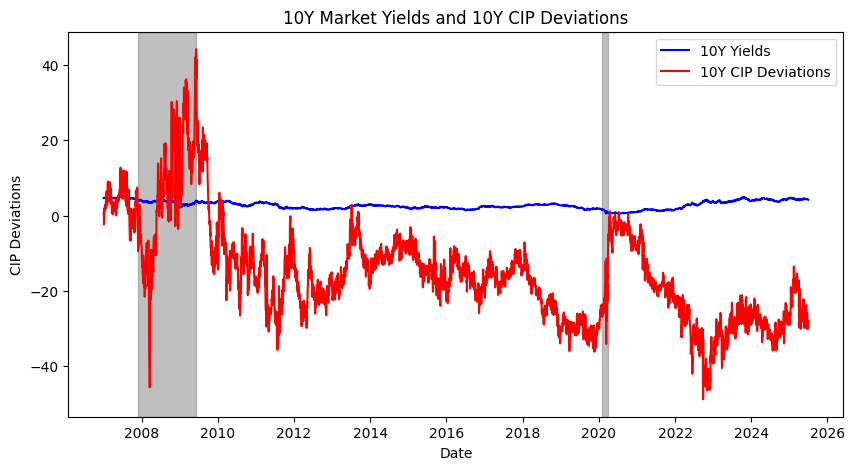

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(merge_10Y_CIP['DGS10'], label = '10Y Yields', color = 'blue')
plt.plot(merge_10Y_CIP['Average CIP Deviations Across G10'], label = '10Y CIP Deviations', color = 'red')

plt.title('10Y Market Yields and 10Y CIP Deviations')
plt.xlabel('Date')
plt.ylabel('CIP Deviations')

plt.axvspan('2007-12-01', '2009-06-01', color='grey', alpha=0.5)
plt.axvspan('2020-02-01', '2020-04-01', color='grey', alpha=0.5)

plt.legend()
plt.show()

3Mo Yields and 3Mo CIP Deviations

In [ ]:
upload = files.upload()

M3_df = pd.read_csv(next(iter(upload)))

Saving 3MonthYield.csv to 3MonthYield (1).csv


In [ ]:
M3_df.index = pd.to_datetime(M3_df['observation_date'])

In [ ]:
M3_df

,observation_date,DGS3MO
observation_date,,
2000-01-03,2000-01-03,5.48
2000-01-04,2000-01-04,5.43
2000-01-05,2000-01-05,5.44
2000-01-06,2000-01-06,5.41
2000-01-07,2000-01-07,5.38
...,...,...
2025-11-28,2025-11-28,3.88
2025-12-01,2025-12-01,3.81
2025-12-02,2025-12-02,3.77


In [ ]:
merge_3Mo_CIP = pd.merge(avg_OECD_df_3m, M3_df, left_index=True, right_index=True, how='right')
merge_3Mo_CIP = merge_3Mo_CIP.dropna()
merge_3Mo_CIP = merge_3Mo_CIP[merge_3Mo_CIP.index > '2007-01-01']

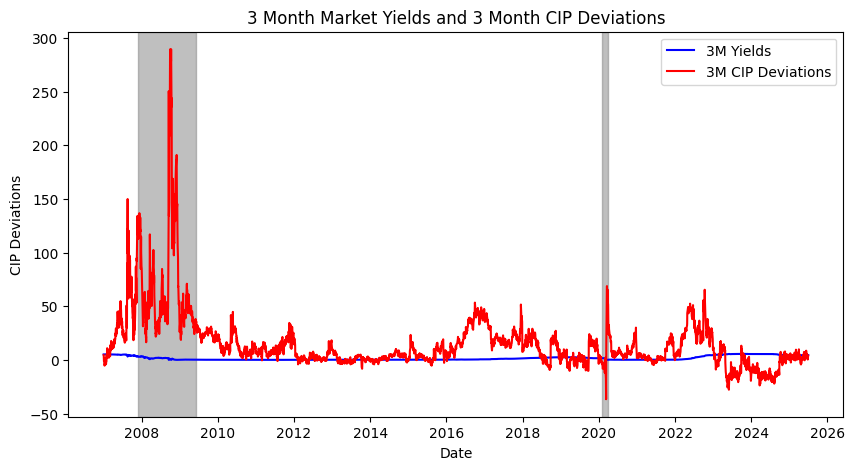

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(merge_3Mo_CIP['DGS3MO'], label = '3M Yields', color = 'blue')
plt.plot(merge_3Mo_CIP['Average CIP Deviations Across G10'], label = '3M CIP Deviations', color = 'red')

plt.title('3 Month Market Yields and 3 Month CIP Deviations')
plt.xlabel('Date')
plt.ylabel('CIP Deviations')

plt.axvspan('2007-12-01', '2009-06-01', color='grey', alpha=0.5)
plt.axvspan('2020-02-01', '2020-04-01', color='grey', alpha=0.5)

plt.legend()
plt.show()

JPY & CHF CIP

/tmp/ipython-input-1664779757.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


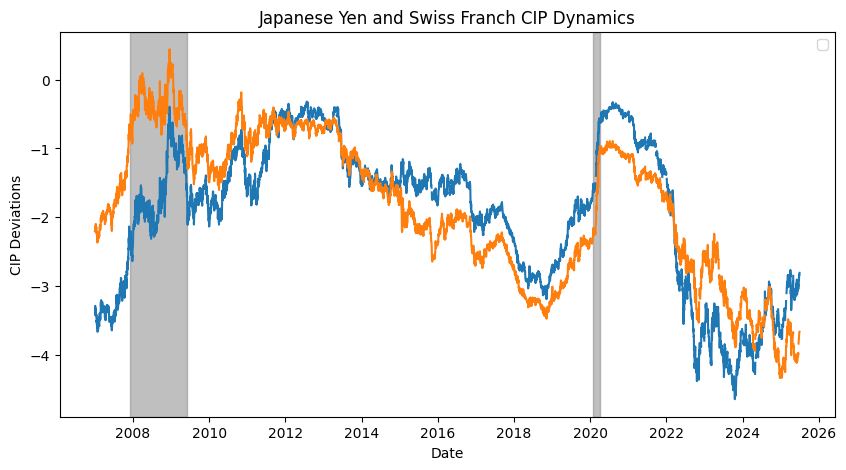

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df_JPY[df_JPY.index > '2007-01-01']['diff_y'])
plt.plot(df_CHF[df_CHF.index > '2007-01-01']['diff_y'])

plt.title('Japanese Yen and Swiss Franch CIP Dynamics')
plt.xlabel('Date')
plt.ylabel('CIP Deviations')

plt.axvspan('2007-12-01', '2009-06-01', color='grey', alpha=0.5)
plt.axvspan('2020-02-01', '2020-04-01', color='grey', alpha=0.5)

plt.legend()
plt.show()

/tmp/ipython-input-3315846637.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


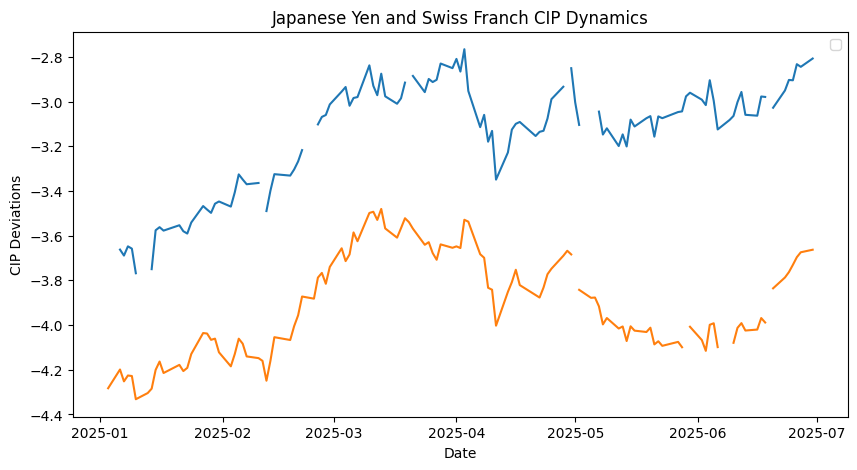

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df_JPY[df_JPY.index > '2025-01-01']['diff_y'])
plt.plot(df_CHF[df_CHF.index > '2025-01-01']['diff_y'])

plt.title('Japanese Yen and Swiss Franch CIP Dynamics')
plt.xlabel('Date')
plt.ylabel('CIP Deviations')

plt.legend()
plt.show()

In [ ]:
df_JPY['diff_y'].corr(df_CHF['diff_y'])

np.float64(0.6235402585053196)

Euro CIP Analysis

/tmp/ipython-input-1869898896.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


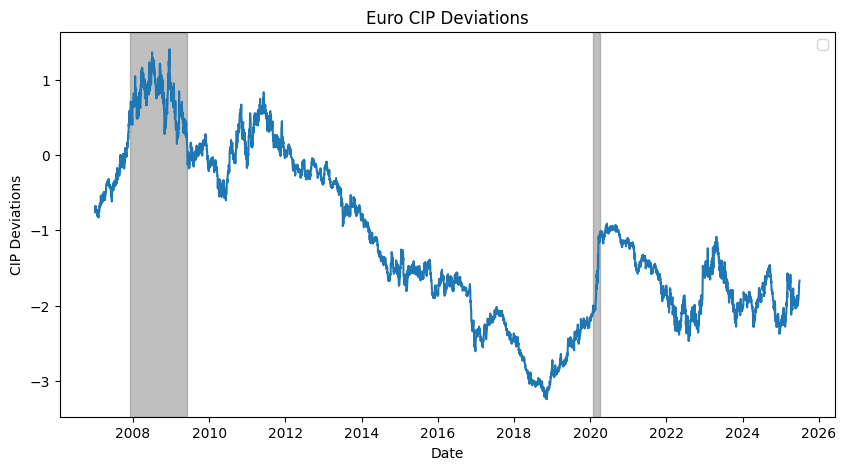

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df_EUR[df_EUR.index > '2007-01-01']['diff_y'])

plt.title('Euro CIP Deviations')
plt.xlabel('Date')
plt.ylabel('CIP Deviations')

plt.axvspan('2007-12-01', '2009-06-01', color='grey', alpha=0.5)
plt.axvspan('2020-02-01', '2020-04-01', color='grey', alpha=0.5)

plt.legend()
plt.show()

/tmp/ipython-input-2703804696.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


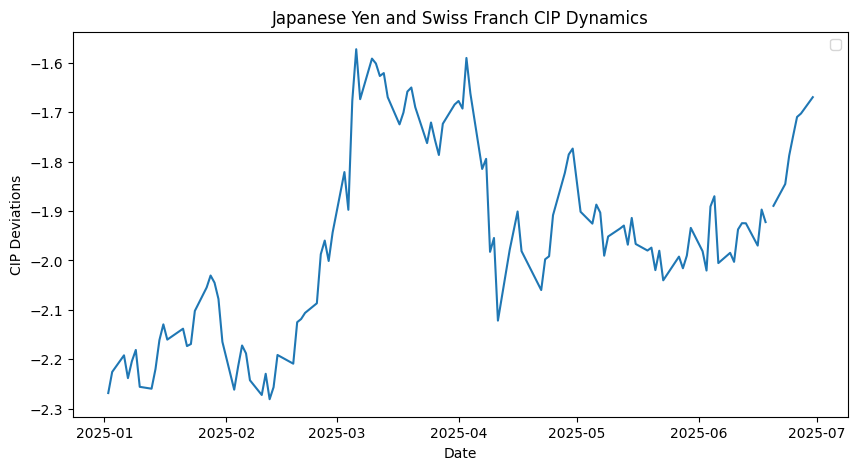

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(df_EUR[df_EUR.index > '2025-01-01']['diff_y'])

plt.title('Japanese Yen and Swiss Franch CIP Dynamics')
plt.xlabel('Date')
plt.ylabel('CIP Deviations')

plt.legend()
plt.show()

In [ ]:
#End with multivariate regression with adjusted R^2

In [ ]:
# 4-5 Factors:
# 1 USD-EUR 10Y Spread
# 2 VIX
# 3 USD (Confounding Between the VIX and the USD?)
# 4 BBB-Treasuries Credit Grade Spreads